# Exploratory Data Analysis: Potential diagnostic Gap in Chronic Kidney Disease (CKD)

### An Exploratory Data Analysis using NHANES (2007–2018)

**Course:** Health Data Visualization  
**Program:** Master in Health Data Science  
**Authors:** [Team members]  
**Date:** [Date]

## Abstract

This exploratory data analysis examines publicly available health data to explore whether there may be a mismatch between laboratory-based indicators of kidney dysfunction and self-reported awareness of chronic kidney disease (CKD).

Using data from the National Health and Nutrition Examination Survey (NHANES) between 2007 and 2018, we compare selected kidney-related laboratory measurements with survey responses regarding prior CKD diagnosis. Rather than estimating disease prevalence or making clinical claims, this analysis uses descriptive statistics and data visualization to highlight patterns that may reflect differences between biological indicators and self-reported awareness.

The project emphasizes data quality, interpretability, and transparent communication, and is intended as a data storytelling exercise rather than an epidemiological or diagnostic study.



## 1. Introduction & Motivation

Chronic Kidney Disease (CKD) is often described as a condition that can remain unnoticed in its early stages. Routine laboratory measurements, such as serum creatinine–based estimates of glomerular filtration rate (eGFR) and markers of kidney damage (e.g., albuminuria), may indicate impaired kidney function before a formal diagnosis is made.”

The purpose of this exploratory analysis is to examine publicly available health survey data and explore whether laboratory indicators of kidney dysfunction align with self-reported awareness or diagnosis of CKD. Rather than testing a formal hypothesis, this notebook focuses on understanding the structure of the data, assessing data quality, and exploring patterns that may suggest a diagnostic gap.


## 2. Guiding Questions for Exploration

This exploratory analysis is guided by the following questions:

- Do individuals with elevated kidney-related laboratory measurements report having been diagnosed with CKD?
- Are there visible patterns suggesting a mismatch between laboratory indicators and diagnosis awareness?
- How do these patterns vary across basic demographic groups such as age and sex?

These questions are intended to guide exploration rather than to be answered conclusively.


## 3. Data Source & Study Period

This analysis uses publicly available data from the  [National Health and Nutrition Examination Survey (NHANES)](https://wwwn.cdc.gov/nchs/nhanes/default.aspx), a continuous program designed to assess the health and nutritional status of the U.S. population.

### Selected Survey Cycles
- 2007–2008
- 2009–2010
- 2011–2012
- 2013–2014
- 2015–2016
- 2017–2018


These cycles were selected to ensure:
- Clinical consistency of kidney-related laboratory measurements (serum creatinine–based eGFR and urinary albumin-to-creatinine indicators)
- Stable survey design prior to the COVID-19 pandemic
- Adequate temporal coverage (~10 years) for descriptive pattern analysis

#datasets files and documentation used:
- Demographics Data -> Containing patient demographic data like sex, age.
- Laboratory Data -> Containing laboratory measuremens used as ckd indicators, specifically serum creatinine and Albumin & Creatinine in urine.
- Questionnaire Data  -> Containing the results of the NHANES survey,  -> specifically questions related to awareness of diminished kidney function.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Display settings (to be able to see complte tables)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## Setting up data directory structure and verfiying proper upload of datasets to drive

In [2]:
# ---- NHANES study cycles included in the analysis -----

# We focus on pre-pandemic NHANES cycles to ensure
# clinical and methodological consistency
cycles = {
    "2007-2008": "E",
    "2009-2010": "F",
    "2011-2012": "G",
    "2013-2014": "H",
    "2015-2016": "I",
    "2017-2018": "J",
}

cycles


{'2007-2008': 'E',
 '2009-2010': 'F',
 '2011-2012': 'G',
 '2013-2014': 'H',
 '2015-2016': 'I',
 '2017-2018': 'J'}

In [3]:
# Define base data directory (Google Drive)

BASE_DATA_DIR = Path.cwd().parent / "dataset"
BASE_DATA_DIR.exists() #expected result -> TRUE

True

In [4]:
# Validate that all cycle folders exist

missing_cycles = []

for cycle in cycles.keys():
    cycle_path = BASE_DATA_DIR / cycle
    if not cycle_path.exists():
        missing_cycles.append(cycle)

missing_cycles #expected result -> empty []


[]

In [5]:

# Validate required NHANES files per cycle

required_files = ["DEMO", "BIOPRO", "KIQ_U", "ALB_CR", "HIQ"]
missing_files = []

for cycle, suffix in cycles.items():
    cycle_path = BASE_DATA_DIR / cycle
    for file_prefix in required_files:
        file_path = cycle_path / f"{file_prefix}_{suffix}.xpt"
        if not file_path.exists():
            missing_files.append(str(file_path))

missing_files   #expected result -> empty []


[]

In [6]:
def load_nhanes_cycle(cycle, suffix, base_dir):
    cycle_path = base_dir / cycle

    demo = pd.read_sas(cycle_path / f"DEMO_{suffix}.xpt", format="xport")
    biopro = pd.read_sas(cycle_path / f"BIOPRO_{suffix}.xpt", format="xport")
    kiq = pd.read_sas(cycle_path / f"KIQ_U_{suffix}.xpt", format="xport")
    albcr = pd.read_sas(cycle_path / f"ALB_CR_{suffix}.xpt", format="xport")
    hiq = pd.read_sas(cycle_path / f"HIQ_{suffix}.xpt", format="xport")

    # Add cycle label for later stratification / time series
    for df in [demo, biopro, kiq, albcr, hiq]:
        df["nhanes_cycle"] = cycle

    return demo, biopro, kiq, albcr, hiq



demo_list, biopro_list, kiq_list, albcr_list, hiq_list = [], [], [], [], []

for cycle, suffix in cycles.items():
        demo, biopro, kiq, albcr, hiq = load_nhanes_cycle(
            cycle, suffix, BASE_DATA_DIR
        )

        demo_list.append(demo)
        biopro_list.append(biopro)
        kiq_list.append(kiq)
        albcr_list.append(albcr)
        hiq_list.append(hiq)

# Concatenate across cycles
demo = pd.concat(demo_list, ignore_index=True)
biopro = pd.concat(biopro_list, ignore_index=True)
kiq = pd.concat(kiq_list, ignore_index=True)
albcr = pd.concat(albcr_list, ignore_index=True)
hiq = pd.concat(hiq_list, ignore_index=True)

## Selected fields for each dataset and description

### Demographics
*   SEQN ->  Respondent sequence number
*   RIDAGEYR -> Age in years at screening (Both males and females 0 YEARS - 150 YEARS)
* RIAGENDR -> Gender of the participant

### Laboratory Data - Standard Biochemistry Profile(BIOPRO_ file)
* SEQN ->  Respondent sequence number
* LBXSCR -> Creatinine, refrigerated serum (mg/dL) -> The CKD laboratory indicator (biomarker of kidney damage, per KDIGO albuminuria categories)*

### Laboratory Data - Albumin & Creatinine - Urine (ALB_CR_ file)
* SEQN ->  Respondent sequence number
* URXUMA (Albumin, urine — µg/mL)-> The CKD laboratory indicator (biomarker of kidney damage, per KDIGO albuminuria categories)*
* URXUCR (Creatinine, urine — mg/dL) -> Supporting CKD biomarker

### Questionnaire Data - Kidney Conditions - Urology	(KIQ_U_ file)
* SEQN ->  Respondent sequence number
* KIQ022 -> Ever told you had weak/failing kidneys? Do not include kidney stones, bladder infections, or incontinence. -> CKD diagnosis proxy. This response shows if the patient has been made aware by her/his physician of a possible CKD*

*Note -> these variables are used as proxies and do not represent a confirmed clinical diagnosis





In [7]:
# Select relevant columns for the analysis
demo_sel = demo[[
    "SEQN",
    "nhanes_cycle",
    "RIDAGEYR",
    "RIAGENDR",
    "DMDEDUC2",
    "INDFMPIR",
    "RIDRETH1"
]]

biopro_sel = biopro[[
    "SEQN",
    "nhanes_cycle",
    "LBXSCR"
]]

albcr_sel = albcr[[
    "SEQN",
    "nhanes_cycle",
    "URXUMA",
    "URXUCR"
]]


**Recoding CKD diagnosis variable (KIQ022)**  
Using the NHANES documentation, we will recode the KIQ022 questionnaire responses following this mapping:

NHANES Code/Value -> NHANES Value Description ->  Meaning  -> recoding for our analysis

1 -> Yes -> ckd diagnosed/aware = 1

2 -> No -> ckd not diagnosed/not aware = 0

7 -> Refused -> Not usable information -> NaN

9 -> Don’t know -> Not usable information -> NaN

. -> Missing -> Not usable information -> NaN



In [8]:
kiq["ckd_diagnosed"] = kiq["KIQ022"].map({
    1: 1,
    2: 0
})

kiq_sel = kiq[[
    "SEQN",
    "nhanes_cycle",
    "ckd_diagnosed"
]]



hiq["hinsu_covered"] = hiq["HIQ011"].map({
    1: 1,
    2: 0
})

hiq_sel = hiq[[
    "SEQN",
    "hinsu_covered",
    "nhanes_cycle"
]]

### Merging the 4 tables into 1 single data frame

In [9]:
df_merged = (
    demo_sel
        .merge(biopro_sel, on=["SEQN", "nhanes_cycle"], how="inner")
        .merge(albcr_sel, on=["SEQN", "nhanes_cycle"], how="inner")
        .merge(kiq_sel, on=["SEQN", "nhanes_cycle"], how="inner")
        .merge(hiq_sel, on=["SEQN", "nhanes_cycle"], how="inner")
)

In [10]:
df_merged.head()

,SEQN,nhanes_cycle,RIDAGEYR,RIAGENDR,DMDEDUC2,INDFMPIR,RIDRETH1,LBXSCR,URXUMA,URXUCR,ckd_diagnosed,hinsu_covered
0,41475.0,2007-2008,62.0,2.0,3.0,1.83,5.0,0.52,7.9,45.0,0.0,0.0
1,41477.0,2007-2008,71.0,1.0,3.0,1.50,3.0,0.76,160.3,135.0,1.0,1.0
2,41479.0,2007-2008,52.0,1.0,1.0,2.20,1.0,0.72,5.3,124.0,0.0,0.0
3,41481.0,2007-2008,21.0,1.0,3.0,1.63,4.0,NaN,11.7,366.0,0.0,0.0
4,41482.0,2007-2008,64.0,1.0,2.0,4.01,1.0,0.70,16.6,130.0,0.0,1.0


In [11]:
df_merged.describe()

,SEQN,RIDAGEYR,RIAGENDR,DMDEDUC2,INDFMPIR,RIDRETH1,LBXSCR,URXUMA,URXUCR,ckd_diagnosed,hinsu_covered
count,33412.000000,33412.000000,33412.000000,33412.000000,3.014700e+04,33412.000000,31278.000000,32595.000000,32595.000000,33364.000000,33368.000000
mean,72120.662696,49.802406,1.515743,3.402610,2.472386e+00,3.060667,0.901059,48.575463,124.115511,0.034049,0.788510
std,18055.122723,17.743183,0.499760,1.287688,1.625276e+00,1.188877,0.454996,346.455455,81.295424,0.181357,0.408371
min,41475.000000,20.000000,1.000000,1.000000,5.397605e-79,1.000000,0.160000,0.210000,3.000000,0.000000,0.000000
25%,56298.500000,35.000000,1.000000,3.000000,1.080000e+00,2.000000,0.710000,4.300000,62.000000,0.000000,1.000000
50%,71237.500000,50.000000,2.000000,4.000000,2.040000e+00,3.000000,0.840000,8.200000,109.000000,0.000000,1.000000
75%,88020.250000,64.000000,2.000000,4.000000,3.980000e+00,4.000000,1.010000,17.400000,168.000000,0.000000,1.000000
max,102956.000000,80.000000,2.000000,9.000000,5.000000e+00,5.000000,17.410000,24440.000000,800.000000,1.000000,1.000000


## Filtering to adult population

The scope of our analysis is limited to adults. Therefore we need to filter the data to include only participants of age 18 or older

In [12]:
df_adults = df_merged[df_merged["RIDAGEYR"]>=18]

In [13]:
df_adults.describe()

,SEQN,RIDAGEYR,RIAGENDR,DMDEDUC2,INDFMPIR,RIDRETH1,LBXSCR,URXUMA,URXUCR,ckd_diagnosed,hinsu_covered
count,33412.000000,33412.000000,33412.000000,33412.000000,3.014700e+04,33412.000000,31278.000000,32595.000000,32595.000000,33364.000000,33368.000000
mean,72120.662696,49.802406,1.515743,3.402610,2.472386e+00,3.060667,0.901059,48.575463,124.115511,0.034049,0.788510
std,18055.122723,17.743183,0.499760,1.287688,1.625276e+00,1.188877,0.454996,346.455455,81.295424,0.181357,0.408371
min,41475.000000,20.000000,1.000000,1.000000,5.397605e-79,1.000000,0.160000,0.210000,3.000000,0.000000,0.000000
25%,56298.500000,35.000000,1.000000,3.000000,1.080000e+00,2.000000,0.710000,4.300000,62.000000,0.000000,1.000000
50%,71237.500000,50.000000,2.000000,4.000000,2.040000e+00,3.000000,0.840000,8.200000,109.000000,0.000000,1.000000
75%,88020.250000,64.000000,2.000000,4.000000,3.980000e+00,4.000000,1.010000,17.400000,168.000000,0.000000,1.000000
max,102956.000000,80.000000,2.000000,9.000000,5.000000e+00,5.000000,17.410000,24440.000000,800.000000,1.000000,1.000000


## Cleaning up the dataframe
We will exclude from the analysis patients that did not have a laboratory result from creatinine and/or dont have usable data from the kidney questionnaire (coded as NaN in previous steps)

In [14]:
df = df_adults.dropna(
    subset=["LBXSCR", "URXUMA", "URXUCR", "ckd_diagnosed"]
).copy()

In [15]:
df.shape

(30761, 12)

## Convert to integer variables

In [16]:
df["SEQN"] = df["SEQN"].astype('Int64')
df["RIDAGEYR"] = df["RIDAGEYR"].astype('Int64')
df["RIAGENDR"] = df["RIAGENDR"].astype('Int64')
df["DMDEDUC2"] = df["DMDEDUC2"].astype('Int64')
df["RIDRETH1"] = df["RIDRETH1"].astype('Int64')
df["ckd_diagnosed"] = df["ckd_diagnosed"].astype('Int64')
df["hinsu_covered"] = df["hinsu_covered"].astype('Int64')

In [17]:
df.head()

,SEQN,nhanes_cycle,RIDAGEYR,RIAGENDR,DMDEDUC2,INDFMPIR,RIDRETH1,LBXSCR,URXUMA,URXUCR,ckd_diagnosed,hinsu_covered
0,41475,2007-2008,62,2,3,1.83,5,0.52,7.9,45.0,0,0
1,41477,2007-2008,71,1,3,1.50,3,0.76,160.3,135.0,1,1
2,41479,2007-2008,52,1,1,2.20,1,0.72,5.3,124.0,0,0
4,41482,2007-2008,64,1,2,4.01,1,0.70,16.6,130.0,0,1
5,41483,2007-2008,66,1,4,1.14,4,1.36,2.4,58.0,0,1


## exploratory proportion of CKD diagnosis/awereness

In [18]:
ckd_diagnosed_counts = df['ckd_diagnosed'].value_counts()
ckd_diagnosed_props = df['ckd_diagnosed'].value_counts(normalize=True)

print("Counts of CKD Diagnosed Status:\n", ckd_diagnosed_counts)
print("\nProportions of CKD Diagnosed Status:\n", ckd_diagnosed_props)

Counts of CKD Diagnosed Status:
 ckd_diagnosed
0    29783
1      978
Name: count, dtype: Int64

Proportions of CKD Diagnosed Status:
 ckd_diagnosed
0    0.968206
1    0.031794
Name: proportion, dtype: Float64


In [19]:
# Calculate proportion of CKD Diagnosed Status categories
ckd_diagnosed_pct = (
    df["ckd_diagnosed"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
print("Percentage of CKD Diagnosed Status:\n", ckd_diagnosed_pct)


Percentage of CKD Diagnosed Status:
 ckd_diagnosed
0    96.82065
1     3.17935
Name: proportion, dtype: Float64


## Exploratory distribution of Serum Creatinine

count    30761.000000
mean         0.891909
std          0.375816
min          0.160000
25%          0.710000
50%          0.840000
75%          1.000000
max         12.740000
Name: LBXSCR, dtype: float64 9.657901532462331


C:\Users\vidgo\AppData\Local\Temp\ipykernel_26916\3915036193.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


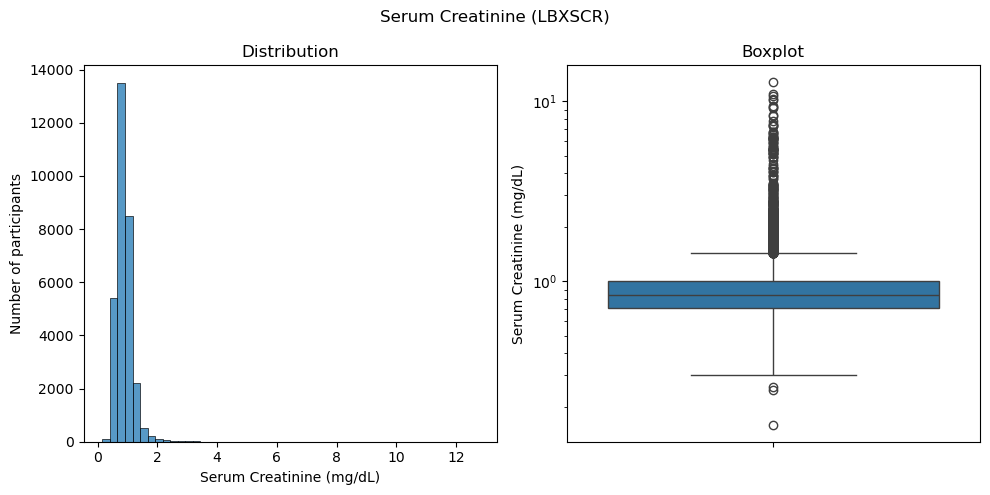

In [20]:
# Exploratory analysis: distribution of serum creatinine (LBXSCR)
print(df["LBXSCR"].describe(), df["LBXSCR"].skew())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Histogram of serum creatinine
sns.histplot(
    data=df,
    x="LBXSCR",
    ax=ax[0],
    bins=50
)
ax[0].set_xlabel("Serum Creatinine (mg/dL)")
ax[0].set_ylabel("Number of participants")
ax[0].set_title("Distribution")

# Boxplot of serum creatinine
sns.boxplot(
    data=df,
    y="LBXSCR",
    ax=ax[1]
)
ax[1].set_yscale("log")
ax[1].set_ylabel("Serum Creatinine (mg/dL)")
ax[1].set_title("Boxplot")
fig.suptitle("Serum Creatinine (LBXSCR)")
fig.tight_layout()
fig.show()


### What we observe in the distribution?
- Right-skewed (asymmetric) distribution -> most individuals have serum creatinine values within the normal range, while a small proportion of participants present very high creatinine levels.
- Clinically expected pattern: chronic kidney disease (CKD) is not prevalent across the general adult population. When present, however, it is associated with substantially elevated creatinine values, resulting in a long right tail in the distribution.

## Exploratory dsitribution of Creatinine and Albumin in urine



count    30761.000000
mean       123.718622
std         80.821053
min          3.000000
25%         62.000000
50%        109.000000
75%        167.000000
max        800.000000
Name: URXUCR, dtype: float64 1.252734369956877
count    30761.000000
mean        47.128019
std        337.643190
min          0.210000
25%          4.200000
50%          8.200000
75%         17.200000
max      24440.000000
Name: URXUMA, dtype: float64 28.480014052920005


C:\Users\vidgo\AppData\Local\Temp\ipykernel_26916\1797557984.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  creatinine.show()
C:\Users\vidgo\AppData\Local\Temp\ipykernel_26916\1797557984.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  albumin.show()


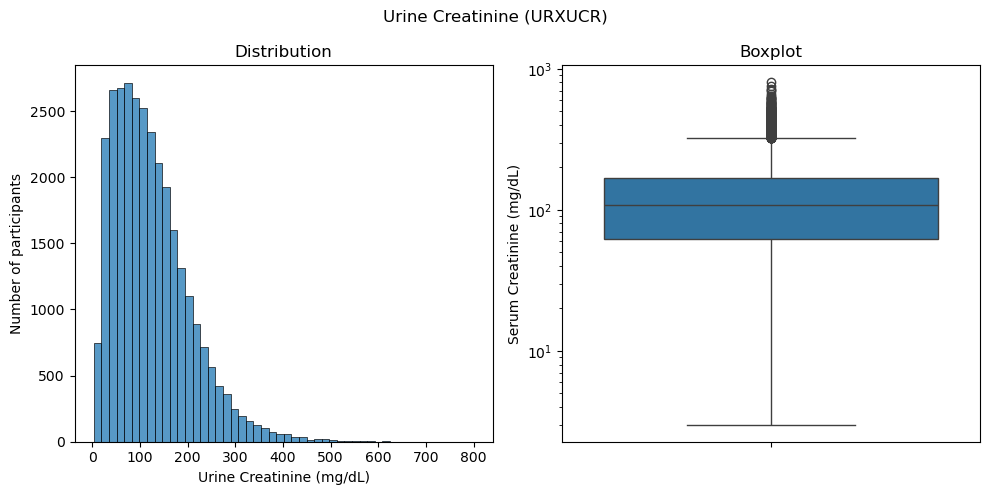

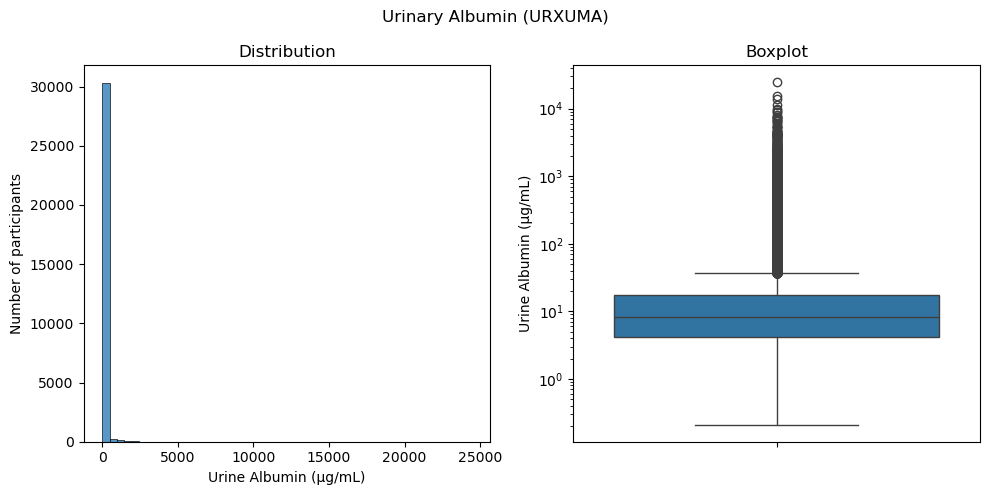

In [21]:
# Exploratory analysis: distribution of creatinine and Albumin in urine

print(df["URXUCR"].describe(), df["URXUCR"].skew())
print(df["URXUMA"].describe(), df["URXUMA"].skew())

# Urine Creatinine
creatinine, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(
    data=df,
    x="URXUCR",
    ax=ax[0],
    bins=50
)
ax[0].set_xlabel("Urine Creatinine (mg/dL)")
ax[0].set_ylabel("Number of participants")
ax[0].set_title("Distribution")

# Boxplot of serum creatinine
sns.boxplot(
    data=df,
    y="URXUCR",
    ax=ax[1]
)
ax[1].set_yscale("log")
ax[1].set_ylabel("Serum Creatinine (mg/dL)")
ax[1].set_title("Boxplot")
creatinine.suptitle("Urine Creatinine (URXUCR)")
creatinine.tight_layout()
creatinine.show()

#Histogram of Urine Albumin
# Urine Creatinine
albumin, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(
    data=df,
    x="URXUMA",
    ax=ax[0],
    bins=50
)
ax[0].set_xlabel("Urine Albumin (µg/mL)")
ax[0].set_ylabel("Number of participants")
ax[0].set_title("Distribution")

# Boxplot of serum creatinine
sns.boxplot(
    data=df,
    y="URXUMA",
    ax=ax[1]
)
ax[1].set_yscale("log")
ax[1].set_ylabel("Urine Albumin (µg/mL)")
ax[1].set_title("Boxplot")
albumin.suptitle("Urinary Albumin (URXUMA)")
albumin.tight_layout()
albumin.show()

### What we observe in the distribution?
- Creatinine in Urine -> distribution relatively stable, with a slight right tail -> high values could be present also in concentratedurine due to dehydration, muscule mass, etc. without representing disease
- Albumin in Urine -> highly Right-skewed (asymmetric) distribution -> most individuals have low values of albumin in urine, while a small proportion of participants present very high levels of albumin in urine. This is clinically expected as high levels of albumin in urine is a signal of a possible kidney damage

The marked assymetri supports the use of albumin to creatinine ratio for subsequent analysis

## Calculate eGFR value from Serum Creatinine

We calculate the eGFR value for each patient using the Serum Creatinene value from the database, following calculation formula available in clinical practice:

### CKD-EPI Creatinine Equation (2021)
Expressed as a single equation:
$$
eGFR_{cr} = 142 * min(S_{cr}/K, 1)^\alpha * max(S_{cr}/K, 1)^{-1.200} * 0.9938*{Age} * 1.012 [if female]
$$

where:

$S_{cr}$ = standardized serum creatinine in $mg/dL$  
$K$ = 0.7 (females) or 0.9 (males)  
$\alpha$ = -0.241 (females) or -0.302 (males)  
$min(S_{cr}/K, 1)$ is the minimum of $S_{cr}$º

In [22]:

# Calculate eGFR using CKD-EPI Creatinine Equation (2021)

# Assumptions:
# - LBXSCR is serum creatinine in mg/dL
# - RIDAGEYR is age in years
# - RIAGENDR: 1 = Male, 2 = Female
# - Adults only (>=18 years), already filtered
# ---------------------------------------------------------


# Define sex-specific parameters
k = np.where(df["RIAGENDR"] == 2, 0.7, 0.9)
alpha = np.where(df["RIAGENDR"] == 2, -0.241, -0.302)
female_multiplier = np.where(df["RIAGENDR"] == 2, 1.012, 1.0)

# Serum creatinine ratio
scr_k = df["LBXSCR"] / k

# CKD-EPI 2021 equation
df["egfr_value"] = (
    142
    * np.minimum(scr_k, 1) ** alpha
    * np.maximum(scr_k, 1) ** -1.200
    * (0.9938 ** df["RIDAGEYR"])
    * female_multiplier
)

 # Exploratory analysis
print(f"eGFR value distribution: \n{df["egfr_value"].describe()}")
print(f"\nMissing values: {df["egfr_value"].isna().sum()}")
print(f"\nSkweness: {df["egfr_value"].skew()}")

eGFR value distribution: 
count       30761.0
mean      94.747798
std       22.597449
min        3.819257
25%       80.680518
50%       97.513272
75%      111.590351
max      179.712795
Name: egfr_value, dtype: Float64

Missing values: 0

Skweness: -0.6440122815736323


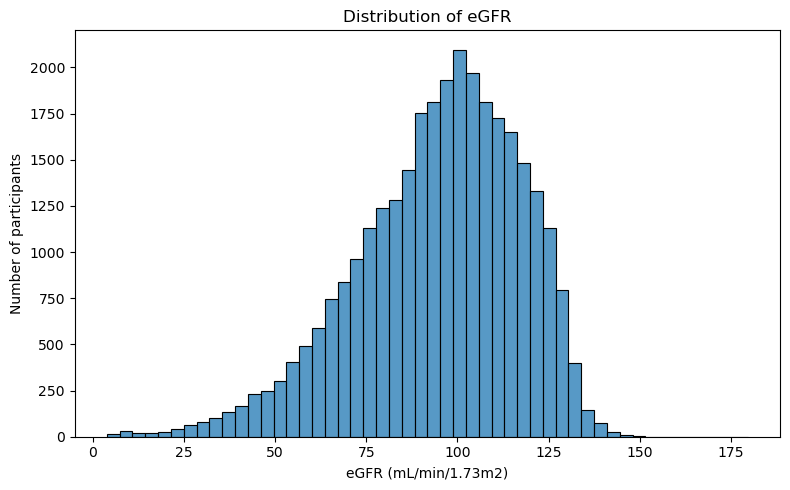

In [23]:
# Histogram of eGFR
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="egfr_value",
    bins=50,
    kde=False
)

plt.title("Distribution of eGFR")
plt.xlabel("eGFR (mL/min/1.73m2)")
plt.ylabel("Number of participants")
plt.tight_layout()
plt.show()

The eGFR distribution is unimodal and slightly left-skewed. Most participants present values within the normal or mildly decreased range, while a smaller proportion shows reduced kidney function (eGFR <60 mL/min/1.73m²), forming a clinically relevant left tail. This pattern is consistent with expectations for a general adult population

## Create eGFR CKD biomarker categories
For creating the eGFR CKD biomaker categories label we use the values reported in clinical guidelines:
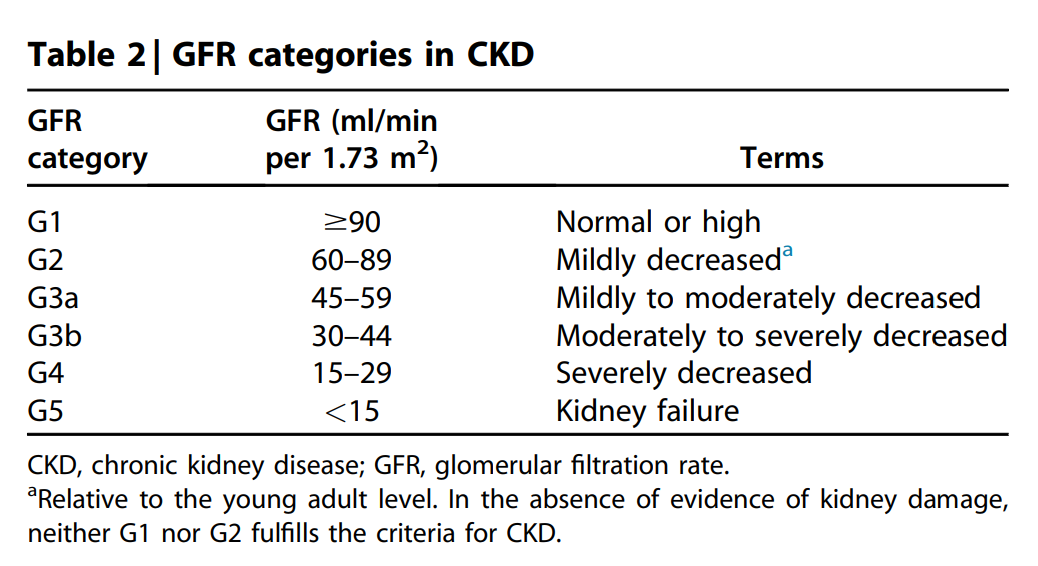

In [24]:
# Create eGFR categories according to KDIGO guidelines
df["egfr_cat"] = pd.cut(
    df["egfr_value"],
    bins=[-np.inf, 15, 30, 45, 60, 90, np.inf],
    labels=["G5", "G4", "G3b", "G3a", "G2", "G1"],
    right=False
)

# Sanity check: distribution of eGFR categories
df["egfr_cat"].value_counts().sort_index()


egfr_cat
G5        74
G4       185
G3b      618
G3a     1488
G2      9135
G1     19261
Name: count, dtype: int64

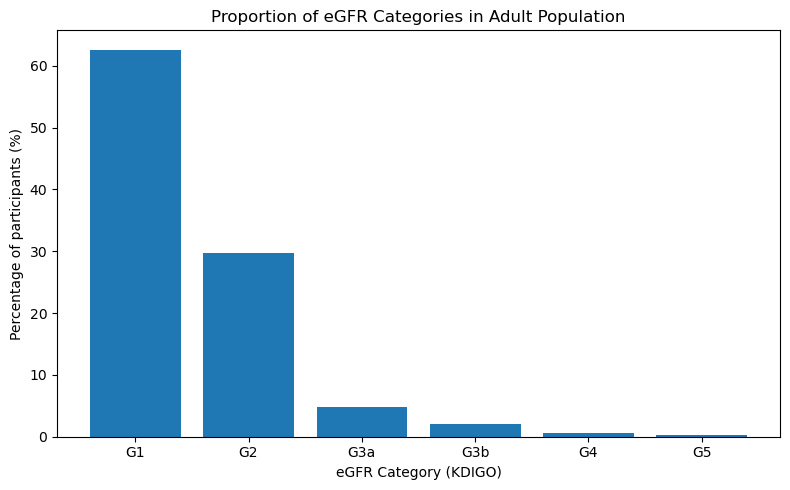

In [25]:
# Calculate proportions of eGFR categories
egfr_counts = (
    df["egfr_cat"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

ordering = ["G1", "G2", "G3a", "G3b", "G4", "G5"]
egfr_counts = egfr_counts.reindex(ordering)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(egfr_counts.index, egfr_counts.values)

plt.xlabel("eGFR Category (KDIGO)")
plt.ylabel("Percentage of participants (%)")
plt.title("Proportion of eGFR Categories in Adult Population")

plt.tight_layout()
plt.show()


## Calculate Albumin-to-Creatine (ACR/uACR) in Urine ratio

 ACR is calculated by dividing albumin concentration in milligrams by creatinine concentration in grams.

 **How to calculate ACR?**  
Let's calculate the albumin-to-creainine ratio in the easiest way possible:

1. **Find the albumin level in urine in $mg/dL$** - e.g., 10 mg/dL.
2. **Write down the creatinine concentration in $g/dL$** - e.g., 150 mg/dl = 0.15 g/dL.
3. **Use the equation**:

$$
ACR = \frac{Albumin}{Creatinine} = \frac{10 mg/dL}{0.15 g/dL}  = 66.7 mg/g
$$

4. **Here's the result** - your ACR is equal to 66.7 mg/g. This value is classified as **moderately increased**.

In [26]:
# Calculate urine Albumin-to-Creatinine Ratio (uACR) in mg/g

# Step 1: Convert albumin from µg/mL to mg/dL
df["urine_albumin_mg_dl"] = df["URXUMA"] / 10

# Step 2: Convert creatinine from mg/dL to g/dL
df["urine_creatinine_g_dl"] = df["URXUCR"] / 1000

# Step 3: Calculate uACR (mg/g)
df["uacr_value"] = (
    df["urine_albumin_mg_dl"] /
    df["urine_creatinine_g_dl"]
)

# Exploratory analysis: distribution of uACR
print(f"uACR value distribution: \n{df["uacr_value"].describe()}")
print(f"\nMissing values: {df["uacr_value"].isna().sum()}")
print(f"\nSkweness: {df["uacr_value"].skew()}")


uACR value distribution: 
count    30761.000000
mean        47.297482
std        360.006118
min          0.211640
25%          4.657534
50%          7.241379
75%         14.126214
max      21152.173913
Name: uacr_value, dtype: float64

Missing values: 0

Skweness: 24.077019182185854


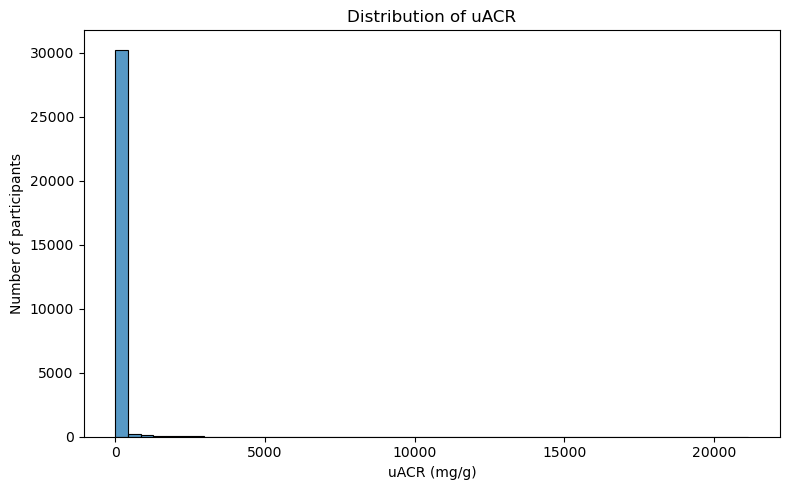

In [27]:
# Histogram of uACR
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="uacr_value",
    bins=50,
    kde=False
)

plt.title("Distribution of uACR")
plt.xlabel("uACR (mg/g)")
plt.ylabel("Number of participants")
plt.tight_layout()
plt.show()

The uACR distribution is highly right-skewed. Most adults show normal to mildly increased albumin excretion (A1), while a small subset presents markedly elevated uACR values consistent with moderate or severe albuminuria (A2–A3). This pattern is clinically expected in population-based samples

## Create the Albumin-to-Creatinine (uACR) CKD biomarker categories

for creating the uACR CKD biomaker categories we following available clinical guidelines:

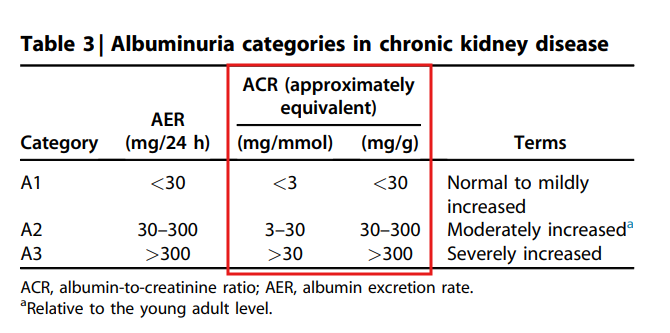


In [28]:
# Assumes you already have: analysis_complete["uacr_value"]

# Create uACR (albuminuria) categories (KDIGO)
df["uacr_cat"] = pd.cut(
    df["uacr_value"],
    bins=[-np.inf, 30, 300, np.inf],
    labels=["A1", "A2", "A3"],
    right=False  # A1: <30, A2: [30,300), A3: >=300
)

# Sanity checks
df["uacr_cat"].value_counts()



uacr_cat
A1    26908
A2     3167
A3      686
Name: count, dtype: int64

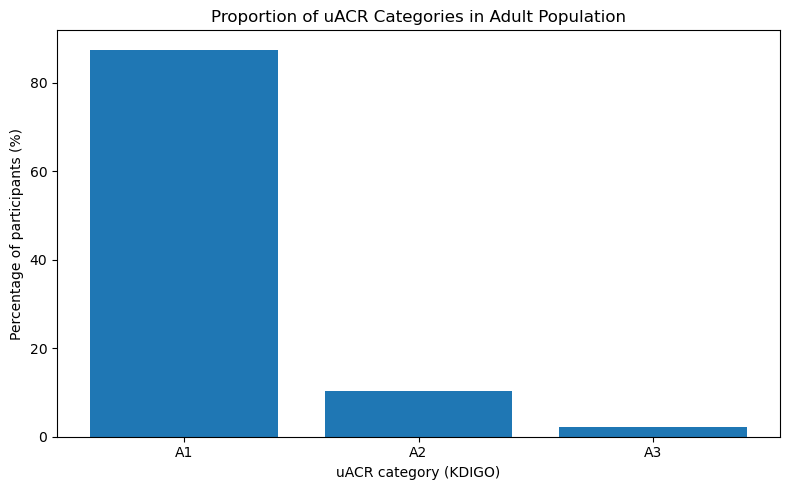

In [29]:
# Calculate proportions of uACR categories
uacr_counts = (
    df["uacr_cat"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(uacr_counts.index, uacr_counts.values)

plt.xlabel("uACR category (KDIGO)")
plt.ylabel("Percentage of participants (%)")
plt.title("Proportion of uACR Categories in Adult Population")

plt.tight_layout()
plt.show()

## Create the CKD progression risk
We now create the CKD progressiong risk categories, based on the combination of uACR categories and eGFR stages/categories, using the following risk matrix per available clinical guidelines

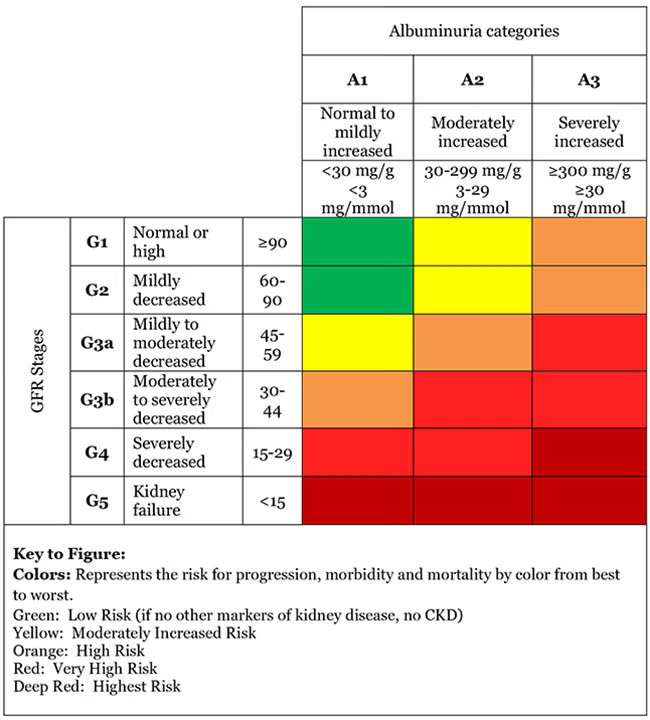

In [30]:
# Define CKD progression risk matrix based on KDIGO guidelines and save to a dictonary
ckd_risk_matrix = {
    ("G1", "A1"): "Low",
    ("G1", "A2"): "Moderate",
    ("G1", "A3"): "High",

    ("G2", "A1"): "Low",
    ("G2", "A2"): "Moderate",
    ("G2", "A3"): "High",

    ("G3a", "A1"): "Moderate",
    ("G3a", "A2"): "High",
    ("G3a", "A3"): "Very High",

    ("G3b", "A1"): "High",
    ("G3b", "A2"): "Very High",
    ("G3b", "A3"): "Very High",

    ("G4", "A1"): "Very High",
    ("G4", "A2"): "Very High",
    ("G4", "A3"): "Highest",

    ("G5", "A1"): "Highest",
    ("G5", "A2"): "Highest",
    ("G5", "A3"): "Highest",
}


In [31]:
# Assign CKD progression risk based on eGFR and uACR categories
df["ckd_risk"] = df.apply(
    lambda row: ckd_risk_matrix.get(
        (row["egfr_cat"], row["uacr_cat"])
    ),
    axis=1
)

# Sanity check: distribution of CKD progression risk categories
df["ckd_risk"].value_counts()



ckd_risk
Low          25441
Moderate      3627
High          1062
Very High      487
Highest        144
Name: count, dtype: int64

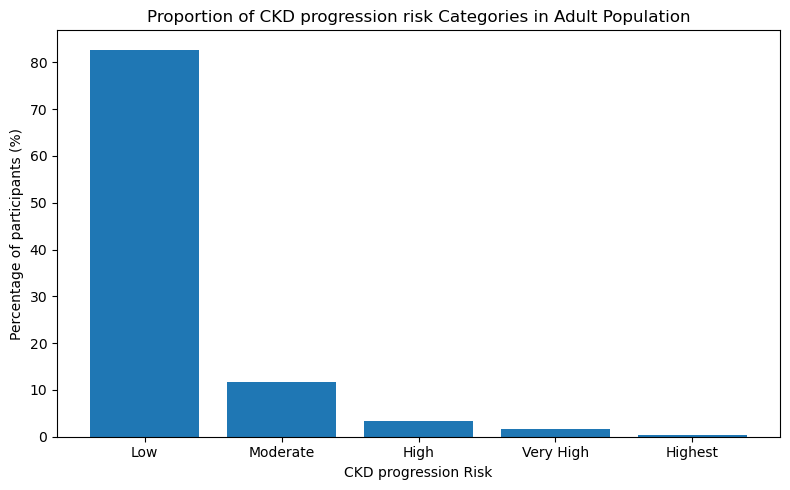

In [32]:
# Calculate proportions of CKD progression risk categories
ckd_counts = (
    df["ckd_risk"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

ordering = ["Low", "Moderate", "High", "Very High", "Highest"]
ckd_counts = ckd_counts.reindex(ordering)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(ckd_counts.index, ckd_counts.values)

plt.xlabel("CKD progression Risk")
plt.ylabel("Percentage of participants (%)")
plt.title("Proportion of CKD progression risk Categories in Adult Population")

plt.tight_layout()
plt.show()

### Proportion of CKD progression risk by age group

In [33]:
age_bins = [18, 40, 60, 80, 120]
age_labels = ["18–39", "40–59", "60–79", "≥80"]

df["age_cat"] = pd.cut(
    df["RIDAGEYR"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [34]:
age_risk = pd.crosstab(
    index = df["age_cat"],
    columns = df["ckd_risk"],
    normalize='index'
) *100

age_risk

ckd_risk,High,Highest,Low,Moderate,Very High
age_cat,,,,,
18–39,0.770581,0.097542,93.601249,5.442840,0.087788
40–59,1.777691,0.293026,88.230123,9.240086,0.459074
60–79,6.113953,0.856429,71.452361,18.437017,3.140240
≥80,15.396996,1.716738,43.186695,30.740343,8.959227


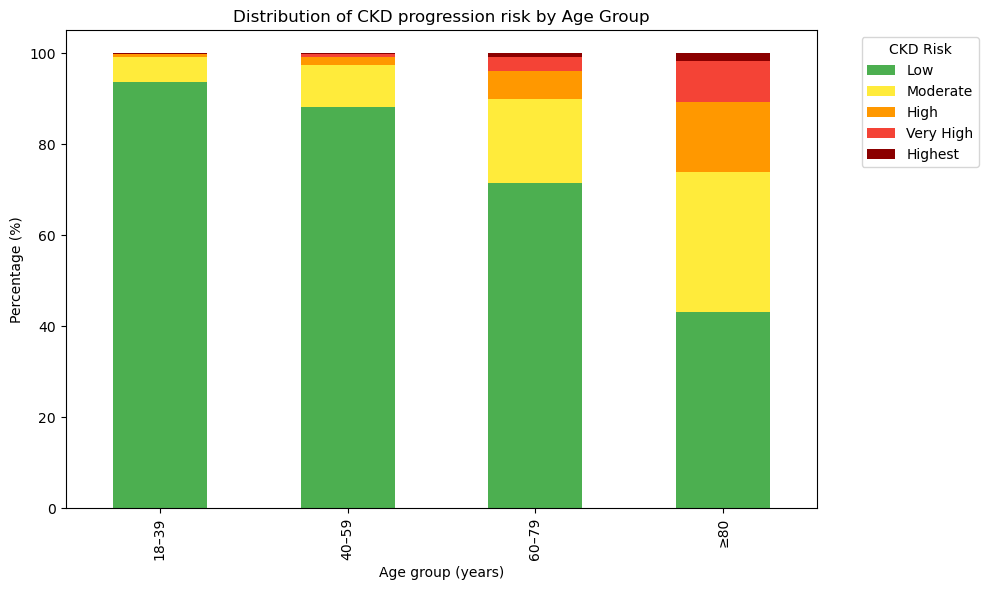

In [35]:
# Stacked bar graph
ordering = ["Low", "Moderate", "High", "Very High", "Highest"]
age_risk = age_risk[ordering]

colors = {
    "Low":       "#4CAF50",  # Green
    "Moderate":  "#FFEB3B",  # Yellow
    "High":      "#FF9800",  # Orange
    "Very High": "#F44336",  # Red
    "Highest":   "#8B0000"   # Dark Red/Wine
}

age_risk.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(10,6)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Age group (years)")
plt.title("Distribution of CKD progression risk by Age Group")

plt.legend(
    title="CKD Risk",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Proportion of CKD progression risk by race

In [36]:
race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race / Multi-Racial",
}

df["RIDRETH1"].value_counts().rename(race_map)

RIDRETH1
Non-Hispanic White           12651
Non-Hispanic Black            6314
Mexican American              4727
Other Race / Multi-Racial     3796
Other Hispanic                3273
Name: count, dtype: Int64

In [37]:
race_risk = pd.crosstab(
    index = df["RIDRETH1"],
    columns = df["ckd_risk"],
    normalize='index'
) *100

race_risk = race_risk.rename(index=race_map)

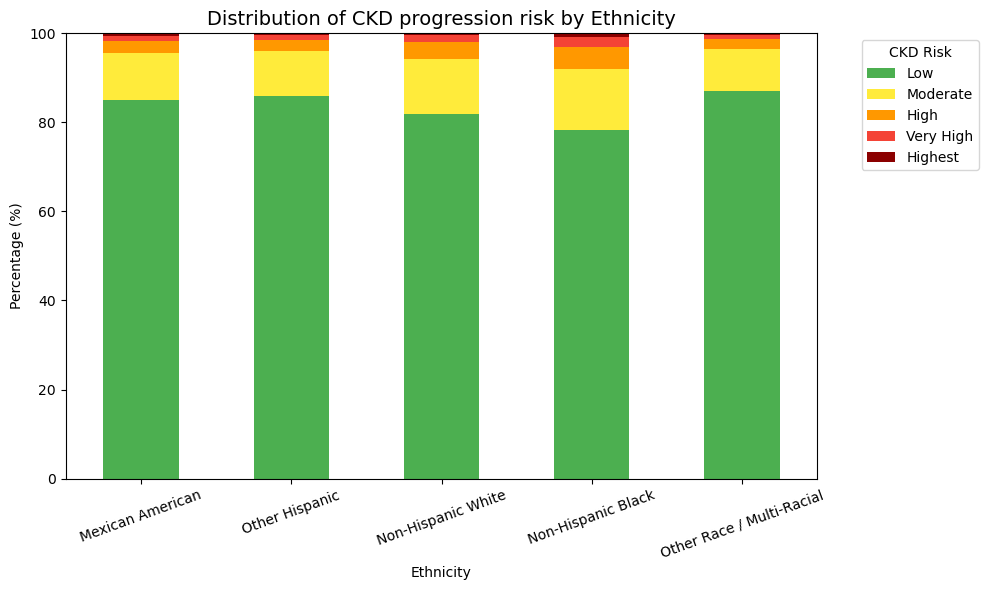

In [38]:
# Stacked bar graph
ordering = ["Low", "Moderate", "High", "Very High", "Highest"]
race_risk = race_risk[ordering]

colors = {
    "Low":       "#4CAF50",  # Green
    "Moderate":  "#FFEB3B",  # Yellow
    "High":      "#FF9800",  # Orange
    "Very High": "#F44336",  # Red
    "Highest":   "#8B0000"   # Dark Red/Wine
}

race_risk.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(10,6)
)

plt.title("Distribution of CKD progression risk by Ethnicity", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Ethnicity")
plt.ylim(0, 100)
plt.xticks(rotation = 20)

plt.legend(
    title="CKD Risk",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## Creating the CKD biomarker status label for further analysis

For the scope of our analysis, we want to identify patients that have strong indicators of CKD and verify if they have been diagnosed with CKD and/or made aware of it, therefore we will group the CKD progression risk categories into a binary variable:

*   High-risk CKD: High, Very High, Highest = 1 -> Patient has CKD biomarkers consistent with a high risk of CKD according to KDIGO (eGFR + uACR)
* Low-risk CKD: Low, Moderate = 0 -> Patient has low CKD risk or no strong biomarker evidence



In [39]:
# Create binary CKD biomarker status based on CKD progression risk
# High-risk CKD: High, Very High, Highest
# Low-risk CKD: Low, Moderate

df["ckd_biomarker"] = df["ckd_risk"].isin(
    ["High", "Very High", "Highest"]
).astype(int)

#sanity check
df["ckd_biomarker"].value_counts()


ckd_biomarker
0    29068
1     1693
Name: count, dtype: int64

In [40]:
ckd_diagnosed_pct = (
    df["ckd_diagnosed"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
print("Percentage of CKD Diagnosed Status:\n", ckd_diagnosed_pct)

Percentage of CKD Diagnosed Status:
 ckd_diagnosed
0    96.82065
1     3.17935
Name: proportion, dtype: Float64


In [41]:
# Calculate proportions for each CKD biomarker group
ckd_biomarker_props = (
    df["ckd_biomarker"]
    .value_counts(normalize=True)
    .sort_index()
    .rename({0: 'Negative', 1: 'Positive'})
    .mul(100)
    .reset_index()
)

ckd_biomarker_props.columns = ["CKD biomarker status", "Percentage"]
print(ckd_biomarker_props)

  CKD biomarker status  Percentage
0             Negative   94.496278
1             Positive    5.503722


## Determining diagnostic gap

For determining if the data shows us a possible CKD diagnostic gap, we will focus our analysis in the patients that have CKD biomarker positive status, this is based on relaible laboratory measurements and clinical guidelines they present a high risk of having CKD.

From this patients we will analyze which proportion of them have evidence of (as self-reported in the NHANS survey):

- being diagnosed with CKD or being aware of a possible CKD
- Not being diagnosed or not being aware of a possible CKD, despite of having laboratory results with clear signs of CKD (diagnostic gap)

In [42]:
confusion_matrix_pct = pd.crosstab(
    index = df["ckd_biomarker"],
    columns = df["ckd_diagnosed"],
    normalize='index'
) *100

confusion_matrix_pct = confusion_matrix_pct.rename(
    index = {0: "Negative", 1: "Positive"},
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
print(confusion_matrix_pct)


ckd_diagnosed  Not diagnosed / not aware  Diagnosed / aware
ckd_biomarker                                              
Negative                       98.114765           1.885235
Positive                       74.601299          25.398701


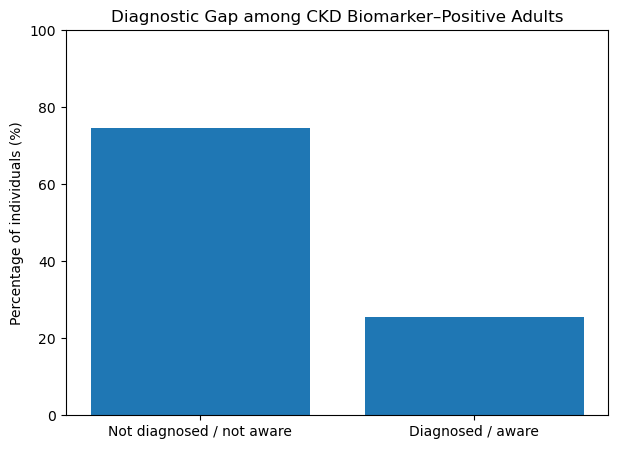

In [43]:
plt.figure(figsize=(7, 5))
plt.bar(
    confusion_matrix_pct.loc["Positive"].index,
    confusion_matrix_pct.loc["Positive"].values,
)

plt.ylabel("Percentage of individuals (%)")
plt.title("Diagnostic Gap among CKD Biomarker–Positive Adults")

plt.ylim(0, 100)
plt.show()

In [44]:
df_pos = df[df["ckd_biomarker"]==1]

Among adults with biomarker-defined high risk of chronic kidney disease (CKD), more than 70% reported not having been previously diagnosed or being unaware of their condition. This finding highlights a substantial diagnostic gap, indicating that the majority of individuals with clinically significant indicators of CKD remain undiagnosed, despite objective evidence of disease based on eGFR and albuminuria criteria.

The literature shows that this problem is present in populations from many countries, with reported diagnostic gaps ranging from 60% to 90%, depending on the stage of the disease. Although these studies already demonstrate that this is a relevant clinical and public health issue that requires targeted interventions, a statistical test was performed to assess whether the observed diagnostic gap is significant compared with what is currently considered an acceptable diagnostic gap (50%).

In [45]:
from scipy.stats import chisquare

# Filtrar biomarcador positivo
df_pos = df[df["ckd_biomarker"] == 1]

# Observed counts: 1 = diagnosed / aware, 0 = not diagnosed / not aware
observed = df_pos["ckd_diagnosed"].value_counts().sort_index().values
# observed[0] = not diagnosed, observed[1] = diagnosed

# Expected counts for 50/50
total = observed.sum()
expected = [total / 2, total / 2]

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Observed counts:", observed)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.6f}")


Observed counts: <IntegerArray>
[1263, 430]
Length: 2, dtype: Int64
Chi-square statistic: 409.858
P-value: 0.000000


To formally assess whether the observed diagnostic gap among individuals with biomarker-defined high risk of CKD could be attributed to random variation, a chi-square goodness-of-fit test was performed. The observed distribution of CKD diagnosis status (diagnosed vs. not diagnosed) among biomarker-positive adults was compared against an expected distribution assuming no diagnostic gap (50/50). The test demonstrated a highly significant deviation from the expected distribution (p < 0.001), indicating that the predominance of undiagnosed individuals is unlikely to be due to chance. This result statistically supports the **presence of a substantial diagnostic gap** among individuals with objective laboratory evidence of CKD.

## CKD positive biomarker across age groups

In [46]:
age_pos_gap = pd.crosstab(
    index = df_pos["age_cat"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

age_pos_gap

ckd_diagnosed,0,1
age_cat,,
18–39,78.571429,21.428571
40–59,73.359073,26.640927
60–79,72.823529,27.176471
≥80,77.572016,22.427984


## Proportion of diagnostic gap by gender

In [47]:
gender_pos_gap = pd.crosstab(
    index = df_pos["RIAGENDR"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

gender_pos_gap = gender_pos_gap.rename(
    index = {1: "Male", 2:"Female"},
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)

print(gender_pos_gap)

ckd_diagnosed  Not diagnosed / not aware  Diagnosed / aware
RIAGENDR                                                   
Male                           72.576832          27.423168
Female                         76.623377          23.376623


In [48]:
def barplot(crossing_table, variable):
    plot_data = (
        crossing_table.iloc[:,0]
        .sort_values(ascending=True)
        .reset_index()
    )

    plot_data.columns = ["Category", "Percentage"]

    plt.figure(figsize=(10,5))
    plt.barh(
        plot_data["Category"],
        plot_data["Percentage"]
    )

    plt.xlabel("Percentage of individuals (%)")
    plt.ylabel(f"{variable} Level")
    plt.title(f"Diagnostic Gap (CKD Not Diagnosed) among Biomarker-Positive Adults\nby {variable}")
    plt.xlim(0, 100)

    for i, value in enumerate(plot_data["Percentage"]):
        plt.text(
            value + 1,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=10
        )

    plt.tight_layout()

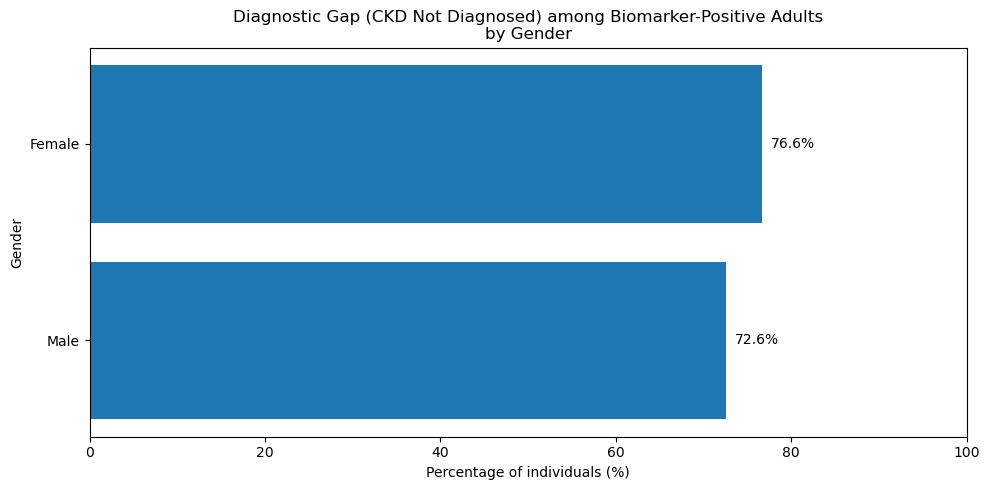

In [49]:
graph = barplot(gender_pos_gap, "Gender")
plt.ylabel("Gender")
plt.show()

In [50]:
contigency_table = pd.crosstab(
    index = df_pos["RIAGENDR"],
    columns = df_pos["ckd_diagnosed"]
)

chi2, p_value, dof, expected = chi2_contingency(contigency_table)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 3.447249751586141
p-value: 0.06335711134077024


No significant difference in diagnostic gap was observed between males and females (p = 0.063).

### Propotion of diagnostic gap by Educational Level

In [51]:
edlevel_pos_gap = pd.crosstab(
    index = df_pos["DMDEDUC2"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

education_labels = {
    1: "Less than 9th grade",
    2: "9-11th grade",
    3: "High school graduate / GED",
    4: "Some college or AA degree",
    5: "College graduate or above",
    7: "Refused",
    9: "Don't know"
}

edlevel_pos_gap = edlevel_pos_gap.rename(
    index = education_labels,
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
edlevel_pos_gap

ckd_diagnosed,Not diagnosed / not aware,Diagnosed / aware
DMDEDUC2,,
Less than 9th grade,78.032787,21.967213
9-11th grade,71.959459,28.040541
High school graduate / GED,77.306733,22.693267
Some college or AA degree,71.621622,28.378378
College graduate or above,74.180328,25.819672
Don't know,100.000000,0.000000


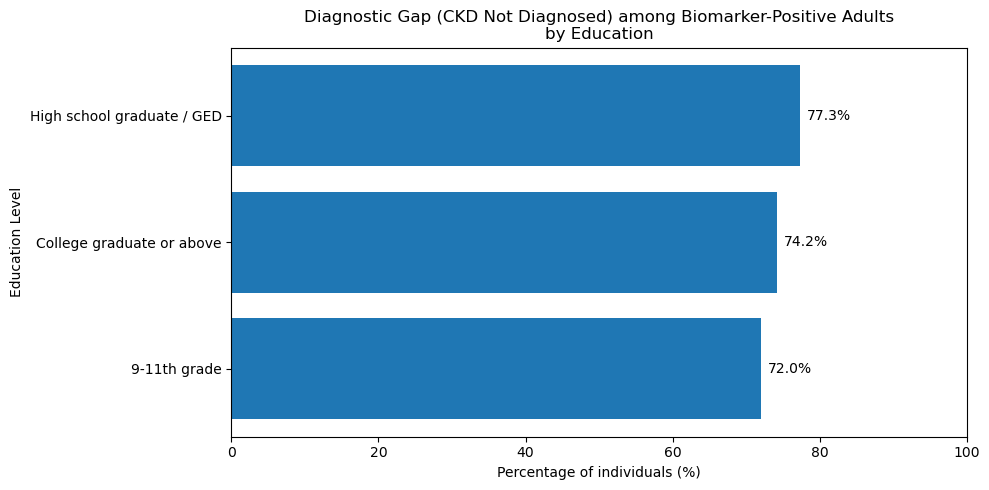

In [52]:
filtered_levels = [
    "9-11th grade",
    "High school graduate / GED",
    "College graduate or above"
]

filt_edlevel_pos_gap = edlevel_pos_gap.loc[filtered_levels]
barplot(filt_edlevel_pos_gap, "Education")

In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

# Filtramos los pacientes biomarcador positivo
df_pos = df[df["ckd_biomarker"] == 1]

# Creamos tabla de contingencia de conteos (no porcentajes)
contingency_table = pd.crosstab(
    index=df_pos["DMDEDUC2"],
    columns=df_pos["ckd_diagnosed"]
)

# Renombramos las filas para interpretar más fácilmente
education_labels = {
    1: "Less than 9th grade",
    2: "9-11th grade",
    3: "High school graduate / GED",
    4: "Some college or AA degree",
    5: "College graduate or above",
    7: "Refused",
    9: "Don't know"
}
contingency_table = contingency_table.rename(index=education_labels, columns={0: "Not diagnosed / not aware", 1: "Diagnosed / aware"})

# Si quieres filtrar solo ciertos niveles educativos:
filtered_levels = ["9-11th grade", "High school graduate / GED", "College graduate or above"]
contingency_table_filtered = contingency_table.loc[filtered_levels]

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_filtered)

print("Contingency Table:\n", contingency_table_filtered)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")


Contingency Table:
 ckd_diagnosed               Not diagnosed / not aware  Diagnosed / aware
DMDEDUC2                                                                
9-11th grade                                      213                 83
High school graduate / GED                        310                 91
College graduate or above                         181                 63

Chi-square statistic: 2.654
Degrees of freedom: 2
P-value: 0.265218


No significant difference in diagnostic gap was observed across education levels (p = 0.265).

### Proportion of diagnostic gap by Ethnicity

In [54]:
ethnicity_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race / Multi-Racial"
}

ethnicity_pos_gap = pd.crosstab(
    index = df_pos["RIDRETH1"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

ethnicity_pos_gap = ethnicity_pos_gap.rename(
    index = ethnicity_labels,
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
ethnicity_pos_gap

ckd_diagnosed,Not diagnosed / not aware,Diagnosed / aware
RIDRETH1,,
Mexican American,71.078431,28.921569
Other Hispanic,71.755725,28.244275
Non-Hispanic White,75.928473,24.071527
Non-Hispanic Black,74.348697,25.651303
Other Race / Multi-Racial,76.515152,23.484848


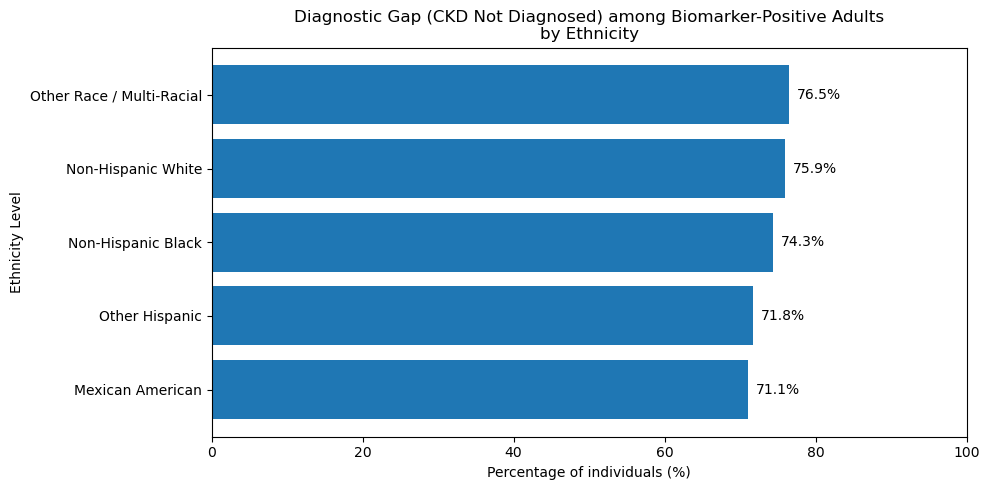

In [55]:
barplot(ethnicity_pos_gap, "Ethnicity")

In [56]:
from scipy.stats import chi2_contingency
import pandas as pd

# Filtramos pacientes biomarcador positivo
df_pos = df[df["ckd_biomarker"] == 1]

# Tabla de contingencia de conteos por etnia
contingency_table = pd.crosstab(
    index=df_pos["RIDRETH1"],
    columns=df_pos["ckd_diagnosed"]
)

# Renombramos filas y columnas para mayor claridad
ethnicity_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race / Multi-Racial"
}
contingency_table = contingency_table.rename(index=ethnicity_labels,
                                             columns={0: "Not diagnosed / not aware",
                                                      1: "Diagnosed / aware"})

print("Contingency Table:\n", contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")


Contingency Table:
 ckd_diagnosed              Not diagnosed / not aware  Diagnosed / aware
RIDRETH1                                                               
Mexican American                                 145                 59
Other Hispanic                                    94                 37
Non-Hispanic White                               552                175
Non-Hispanic Black                               371                128
Other Race / Multi-Racial                        101                 31

Chi-square statistic: 2.844
Degrees of freedom: 4
P-value: 0.584295


No significant difference in diagnostic gap was observed across ethnic groups (p = 0.584).

### Proportion of diagnostic gap by Poverty

The variable INDFMPIR represents the ratio of family income to the federal poverty guidelines. To facilitate analysis and visualization, we grouped the continuous income-to-poverty ratio into four categories. The bins were defined as [-0.01, 1, 3, 4.98, ∞] corresponding to the labels “Poor,” “Near Poor,” “Middle Class,” and “Affluent.”

This categorization was chosen to reflect meaningful socioeconomic strata:

Poor includes families with income below the poverty threshold (ratio ≤ 1),

Near Poor represents families slightly above the poverty line (1 < ratio ≤ 3),

Middle Class includes families with moderate income (3 < ratio ≤ 4.98),

Affluent captures high-income families (ratio > 4.98).

This binning allows for more interpretable comparisons across socioeconomic groups and helps reveal associations between poverty, insurance coverage, and the CKD diagnostic gap.

In [57]:
bins = [-0.01, 1, 3, 4.98, float('inf')]
poverty_labels = [
    "Poor",
    "Near Poor",
    "Middle Class",
    "Affluent"
]

poverty_category = pd.cut(
    df_pos["INDFMPIR"],
    bins=bins,
    labels=poverty_labels
)

poverty_pos_gap = pd.crosstab(
    index = poverty_category,
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

poverty_pos_gap = poverty_pos_gap.rename(
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
poverty_pos_gap

ckd_diagnosed,Not diagnosed / not aware,Diagnosed / aware
INDFMPIR,,
Poor,73.614776,26.385224
Near Poor,75.033025,24.966975
Middle Class,74.407583,25.592417
Affluent,78.289474,21.710526


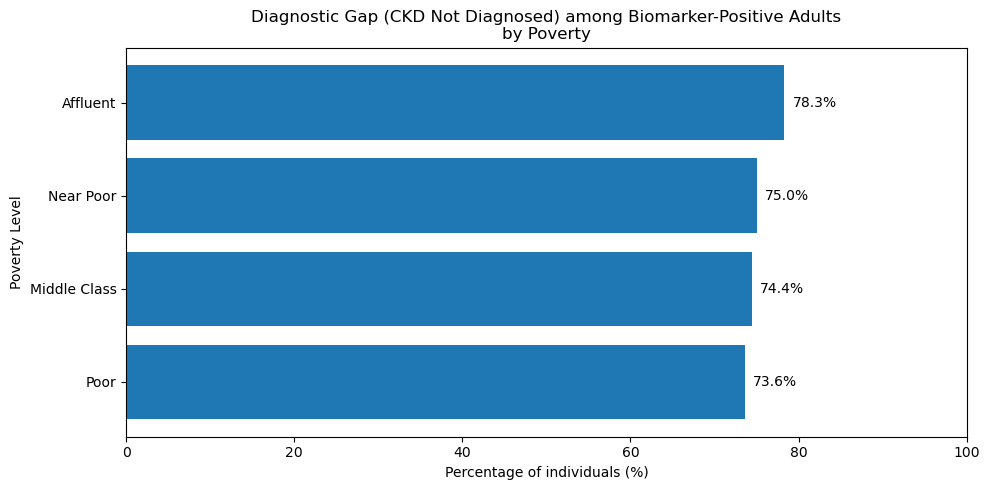

In [58]:
barplot(poverty_pos_gap, "Poverty")

In [59]:
from scipy.stats import chi2_contingency
import pandas as pd

# Filtramos pacientes biomarcador positivo
df_pos = df[df["ckd_biomarker"] == 1]

# Creamos variable categórica de pobreza
bins = [-0.01, 1, 3, 4.98, float('inf')]
poverty_labels = ["Poor", "Near Poor", "Middle Class", "Affluent"]

poverty_category = pd.cut(df_pos["INDFMPIR"], bins=bins, labels=poverty_labels)

# Tabla de contingencia de conteos
contingency_table = pd.crosstab(
    index=poverty_category,
    columns=df_pos["ckd_diagnosed"]
)

# Renombramos columnas para mayor claridad
contingency_table = contingency_table.rename(columns={0: "Not diagnosed / not aware",
                                                      1: "Diagnosed / aware"})

print("Contingency Table:\n", contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")


Contingency Table:
 ckd_diagnosed  Not diagnosed / not aware  Diagnosed / aware
INDFMPIR                                                   
Poor                                 279                100
Near Poor                            568                189
Middle Class                         157                 54
Affluent                             119                 33

Chi-square statistic: 1.297
Degrees of freedom: 3
P-value: 0.729952


No significant difference in diagnostic gap was observed across poverty categories (p = 0.730).

### Proportion of diagnostic gap by Health Insurance

In [60]:
hinsurance_pos_gap = pd.crosstab(
    index = df_pos["hinsu_covered"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
) *100

hinsurance_pos_gap = hinsurance_pos_gap.rename(
    index = {0: "No health insurance", 1: "Covered by health insurance"},
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
hinsurance_pos_gap

ckd_diagnosed,Not diagnosed / not aware,Diagnosed / aware
hinsu_covered,,
No health insurance,85.534591,14.465409
Covered by health insurance,73.515982,26.484018


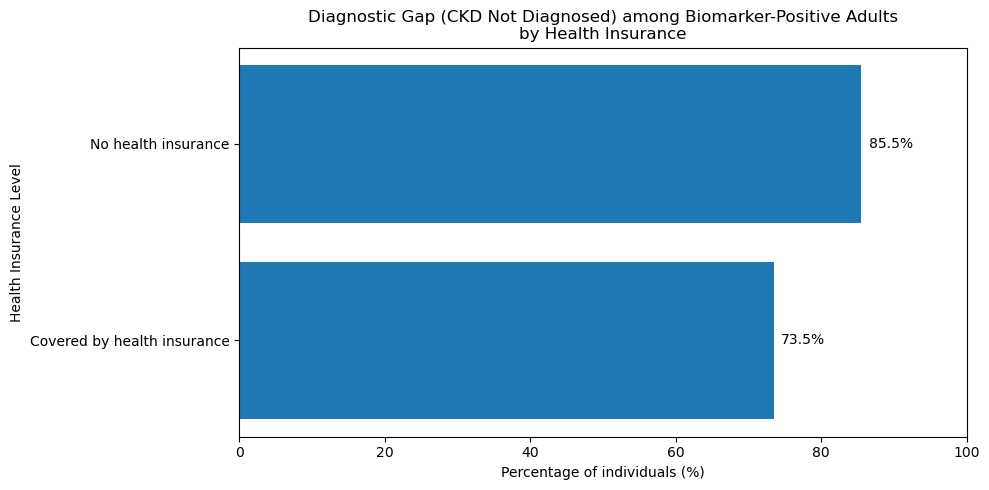

In [61]:
barplot(hinsurance_pos_gap, "Health Insurance")

In [62]:
contingency_table = pd.crosstab(
    index = df_pos["hinsu_covered"],
    columns = df_pos["ckd_diagnosed"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

Chi-square statistic: 10.369
Degrees of freedom: 1
P-value: 0.0013


Diagnostic gap is significantly associated with health insurance coverage (p = 0.001), with uninsured patients more likely to be undiagnosed.

## Timeseries diagnostic gap

In [63]:
cycle_gap = pd.crosstab(
    index = df_pos["nhanes_cycle"],
    columns = df_pos["ckd_diagnosed"],
    normalize = 'index'
)

cycle_gap = cycle_gap.rename(
    columns = {0: "Not diagnosed / not aware", 1: "Diagnosed / aware"}
)
cycle_gap

ckd_diagnosed,Not diagnosed / not aware,Diagnosed / aware
nhanes_cycle,,
2007-2008,0.800000,0.200000
2009-2010,0.774306,0.225694
2011-2012,0.752650,0.247350
2013-2014,0.753788,0.246212
2015-2016,0.704626,0.295374
2017-2018,0.685921,0.314079


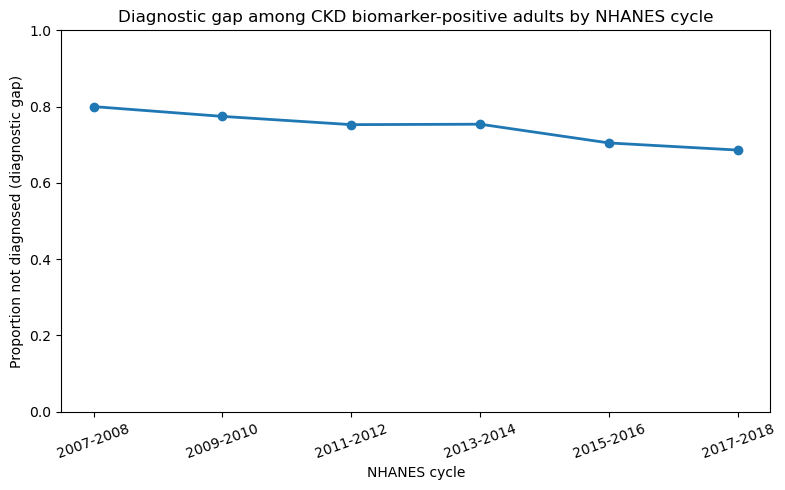

In [64]:
plt.figure(figsize=(8,5))
plt.plot(
    cycle_gap.index,
    cycle_gap["Not diagnosed / not aware"],
    marker = 'o',
    linestyle = '-',
    linewidth = 2
)

plt.ylim(0, 1)
plt.ylabel("Proportion not diagnosed (diagnostic gap)")
plt.xlabel("NHANES cycle")
plt.title("Diagnostic gap among CKD biomarker-positive adults by NHANES cycle")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Percentage of uninsured by Poverty level

In [65]:
poverty_hinsu_gap = pd.crosstab(
    index = poverty_category,
    columns = df_pos["hinsu_covered"],
    normalize = 'index'
) *100

poverty_hinsu_gap = poverty_hinsu_gap.rename(
    columns = {0: "Not covered", 1: "Covered"}
)
poverty_hinsu_gap

hinsu_covered,Not covered,Covered
INDFMPIR,,
Poor,17.941953,82.058047
Near Poor,7.397622,92.602378
Middle Class,4.739336,95.260664
Affluent,2.631579,97.368421


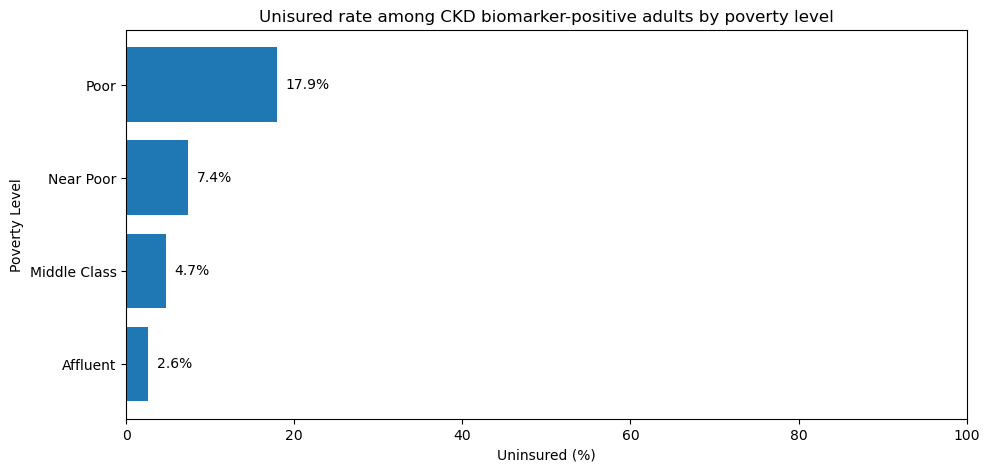

In [66]:
barplot(poverty_hinsu_gap, "Poverty")
plt.xlabel("Uninsured (%)")
plt.title("Unisured rate among CKD biomarker-positive adults by poverty level")
plt.show()

## ODDS ratio

In [67]:
df_pos["poverty_cat"] = pd.cut(
    df_pos["INDFMPIR"],
    bins=[-np.inf, 1, 3, 4.98, np.inf],
    labels=poverty_labels)

In [68]:
def calculate_or(df, cat_col, ref_label, mapping_dict=None):
    if mapping_dict:
        series_mapped = df[cat_col].map(mapping_dict)
    else:
        series_mapped = df[cat_col]

    crosstab = pd.crosstab(series_mapped, df["ckd_diagnosed"])
    if ref_label not in crosstab.index:
        return pd.DataFrame()

    results = []

    ref_gap = crosstab.loc[ref_label, 0]
    ref_diag = crosstab.loc[ref_label, 1]

    for category in crosstab.index:
        if category == ref_label:
            continue

        cat_gap = crosstab.loc[category, 0]
        cat_diag = crosstab.loc[category, 1]

        or_val = (cat_gap*ref_diag) / (cat_diag*ref_gap)

        se = np.sqrt(1/cat_gap + 1/cat_diag + 1/ref_gap + 1/ref_diag)
        ci_lower = np.exp(np.log(or_val) - 1.96*se)
        ci_upper = np.exp(np.log(or_val) + 1.96*se)

        results.append({
            "Variable": cat_col,
            "Group": category,
            "OR": or_val,
            "Lower CI": ci_lower,
            "Upper CI": ci_upper,
            "Reerence": ref_label
        })

    return pd.DataFrame(results)

In [69]:
df_pos["age_cat"].unique()

['60–79', '≥80', '40–59', '18–39']
Categories (4, str): ['18–39' < '40–59' < '60–79' < '≥80']

In [70]:
analyses = [
    {
        "col": "hinsu_covered",
        "map": {1: "Covered", 0: "Uninsured"},
        "ref": "Covered"
    },
    {
        "col": "poverty_cat",
        "map": None,
        "ref": "Affluent"
    },
    {
        "col": "RIAGENDR",
        "map": {1: "Male", 2: "Female"},
        "ref": "Male"
    },
    {
        "col": "age_cat",
        "map": None,
        "ref": "18–39"
    },
    {
        "col": "RIDRETH1",
        "map": {1: "Mexican", 2: "Hispanic", 3: "White", 4: "Black", 5: "Other"},
        "ref": "White"
    },
    {
        "col": "DMDEDUC2",
        "map": {2: "9-11th grade", 3: "High school graduate / GED", 5: "College graduate or above"},
        "ref": "9-11th grade"
    }
]
all_results = pd.DataFrame()
for config in analyses:
    res = calculate_or(df_pos, config["col"], config["ref"], config["map"])
    all_results = pd.concat([all_results, res])

all_results = all_results.sort_values(by=["Variable","OR"], ascending=True).reset_index(drop=True)
print("Results table (Odds Ratios Univariate):")
print(all_results[["Variable", "Group", "OR", "Lower CI", "Upper CI"]])

Results table (Odds Ratios Univariate):
         Variable                       Group        OR  Lower CI  Upper CI
0        DMDEDUC2   College graduate or above  1.119532  0.763478  1.641635
1        DMDEDUC2  High school graduate / GED  1.327452  0.940261  1.874084
2        RIAGENDR                      Female  1.238509  0.994523  1.542352
3        RIDRETH1                     Mexican  0.779139  0.550614  1.102511
4        RIDRETH1                    Hispanic  0.805425  0.530972  1.221740
5        RIDRETH1                       Black  0.918889  0.706241  1.195564
6        RIDRETH1                       Other  1.032901  0.667300  1.598807
7         age_cat                       60–79  0.730815  0.440773  1.211711
8         age_cat                       40–59  0.750988  0.430852  1.308994
9         age_cat                         ≥80  0.943286  0.556612  1.598581
10  hinsu_covered                   Uninsured  2.130165  1.349820  3.361634
11    poverty_cat                        Poor  0

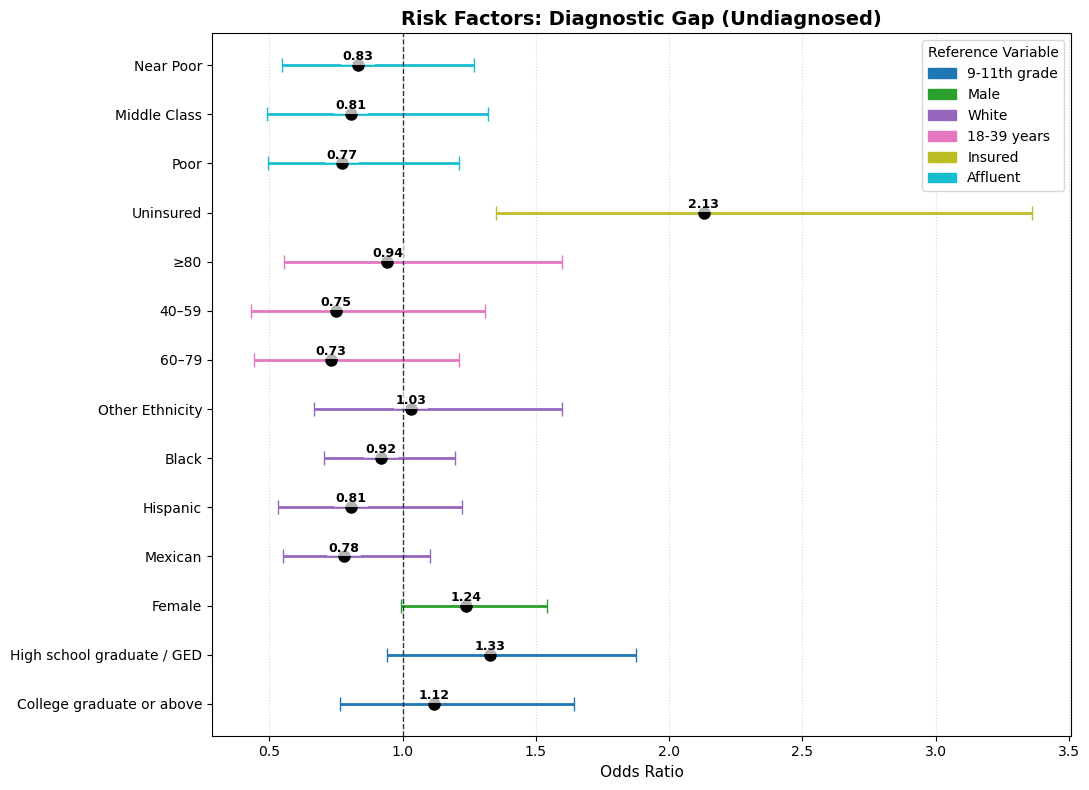

In [71]:
import matplotlib.patches as mpatches

plt.figure(figsize=(11, 8))
y_pos = np.arange(len(all_results))

# Colors per variable
vars_unique = all_results['Variable'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(vars_unique)))
color_map = dict(zip(vars_unique, colors))
bar_colors = all_results['Variable'].map(color_map)

for i, (idx, row) in enumerate(all_results.iterrows()):
    # Error distance
    low_error = row['OR'] - row['Lower CI']
    high_error = row['Upper CI'] - row['OR']

    # Specific color
    c_color = bar_colors.iloc[i]

    # Error plot
    plt.errorbar(
        x=row['OR'],
        y=i,
        xerr=[[low_error], [high_error]],
        fmt='o',
        color='black',
        ecolor=c_color,
        capsize=5,
        markersize=8,
        elinewidth=2
    )

plt.axvline(x=1, color='#333333', linestyle='--', linewidth=1)

labels = all_results['Group'].replace('Other', 'Other Ethnicity')
plt.yticks(y_pos, labels)
plt.title('Risk Factors: Diagnostic Gap (Undiagnosed)', fontsize=14, fontweight='bold')
plt.xlabel('Odds Ratio', fontsize=11)

for i, v in enumerate(all_results['OR']):
    plt.text(v, i + 0.1, f"{v:.2f}", ha='center', fontsize=9, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()

var_names = {
    'RIDRETH1': 'White',
    'RIAGENDR': 'Male',
    'hinsu_covered': 'Insured',
    'poverty_cat': 'Affluent',
    'age_cat': '18-39 years',
    'DMDEDUC2': '9-11th grade'
}
legend_patches = []
for var, color in zip(vars_unique, colors):
    patch = mpatches.Patch(color=color, label=var_names.get(var, var))
    legend_patches.append(patch)

plt.legend(handles=legend_patches, title="Reference Variable", loc="best")

plt.show()

The univariate odds ratio analysis shows that among biomarker-positive individuals, lack of health insurance is the strongest risk factor for being undiagnosed, with an OR of 2.13 (95% CI: 1.35–3.36). Other factors, including age, gender, ethnicity, education, and poverty, show ORs close to 1 and confidence intervals that include 1, indicating no statistically significant association with the diagnostic gap. This highlights that insurance coverage is the primary structural determinant of CKD underdiagnosis in this population.

## Uninsured rate by Poverty and Ethnicity

In [72]:
poverty_hinsu_gap = pd.crosstab(
    index = [poverty_category, df_pos["RIDRETH1"]],
    columns = df_pos["hinsu_covered"],
    normalize = 'index'
) *100

poverty_hinsu_gap = poverty_hinsu_gap.rename(
    columns = {0: "Not covered", 1: "Covered"}
)

# Divide index in two columns (Poverty and Ethnicity)
poverty_hinsu_gap = poverty_hinsu_gap.reset_index()
poverty_hinsu_gap.columns = ["Poverty", "Ethnicity", "Not Covered", "Covered"]
poverty_hinsu_gap["Ethnicity"] = poverty_hinsu_gap["Ethnicity"].map(ethnicity_labels)
poverty_hinsu_gap

,Poverty,Ethnicity,Not Covered,Covered
0,Poor,Mexican American,36.111111,63.888889
1,Poor,Other Hispanic,22.727273,77.272727
2,Poor,Non-Hispanic White,12.389381,87.610619
3,Poor,Non-Hispanic Black,11.864407,88.135593
4,Poor,Other Race / Multi-Racial,12.500000,87.500000
5,Near Poor,Mexican American,19.753086,80.246914
6,Near Poor,Other Hispanic,16.000000,84.000000
7,Near Poor,Non-Hispanic White,3.601108,96.398892
8,Near Poor,Non-Hispanic Black,7.042254,92.957746
9,Near Poor,Other Race / Multi-Racial,7.692308,92.307692


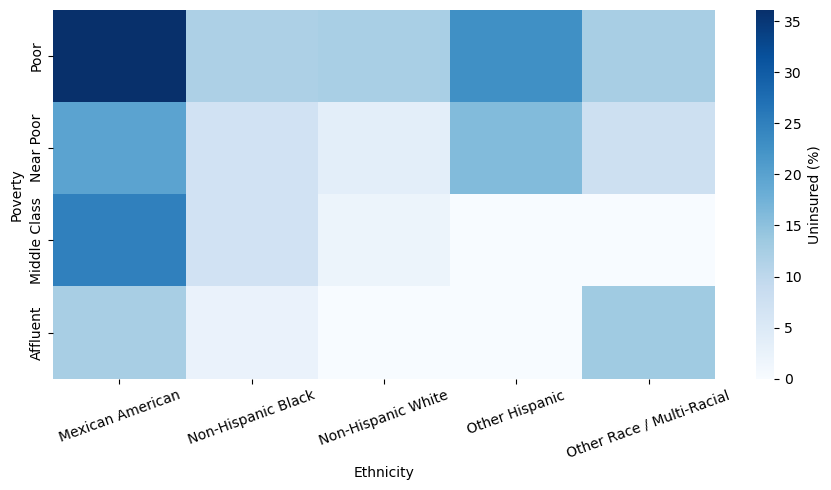

In [73]:
heatmap_matrix = poverty_hinsu_gap.pivot(
    index="Poverty",
    columns="Ethnicity",
    values="Not Covered"
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_matrix,
    annot=False,                          # Values inside each cell
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Uninsured (%)"}
)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [74]:
# Save to CSV
df.to_csv('df_processed.csv',
          sep=';',
          decimal=',',
          index=False,
          encoding='utf-8-sig')

## References


* [KDIGO 2024 Clinical Practice Guideline](https://kdigo.org/wp-content/uploads/2024/03/KDIGO-2024-CKD-Guideline.pdf)
* [CKD-EPI Creatinine Equiation (2021) -  National Kidney Foundation](https://www.kidney.org/ckd-epi-creatinine-equation-2021)
* [Kidney Failure Risk Factor: Urine Albumin-Creatinine Ratio (uACR)](https://www.kidney.org/kidney-failure-risk-factor-urine-albumin-creatinine-ratio-uacr)
* [Urine albumin-creatinine ratio (uACR)](https://www.kidney.org/kidney-topics/urine-albumin-creatinine-ratio-uacr)
* [eGFR calculator](https://www.kidney.org/professionals/gfr_calculator)
* [Albumin Creatinine ratio calculator](https://www.omnicalculator.com/health/acr)
